# 03 — Phân tích Grad-CAM cho CIFAKE

**Mục tiêu:** Hiểu *vì sao* các model phân biệt ảnh thật vs ảnh AI bằng cách nhìn vào vùng pixel mà model **chú ý** (attention) khi đưa ra quyết định.

Notebook này dựa trên dữ liệu đã được sinh sẵn ở `outputs/gradcam_batch/` (xem `scripts/generate_gradcam_batch.py`).

## 1. Grad-CAM là gì?

**Grad-CAM (Gradient-weighted Class Activation Mapping)** trả lời câu hỏi: *"Pixel nào trong ảnh đẩy điểm số lớp dự đoán lên cao?"*

Cách hoạt động (tóm tắt):
1. Cho ảnh qua CNN → lấy **feature map** ở 1 conv layer cuối (gọi là `A`).
2. Tính **gradient** của điểm số lớp dự đoán theo `A`.
3. Trung bình gradient theo trục không gian → **trọng số** cho từng kênh.
4. Tổ hợp tuyến tính các kênh `A` với trọng số → bản đồ nhiệt 2D → ReLU → upsample về kích thước ảnh gốc.

→ Vùng **"nóng" (đỏ)** = vùng model dựa vào để ra quyết định. Vùng **"lạnh" (xanh)** = model bỏ qua.

> Trong project này: target layer = conv block cuối cùng của mỗi kiến trúc (xem `scripts/generate_gradcam_batch.py` → `MODEL_REGISTRY`).

In [17]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = PROJECT_ROOT / "outputs" / "gradcam_batch"
df = pd.read_csv(DATA_DIR / "metadata.csv")
print("Shape:", df.shape)
print()
print("Accuracy theo model (trên 100 mẫu test đầu tiên):")
print(df.groupby("model")["correct"].mean().round(3))
df.head()

Shape: (400, 8)

Accuracy theo model (trên 100 mẫu test đầu tiên):
model
densenet121        0.97
efficientnet_b0    0.91
resnet18           0.94
simple_cnn         0.94
Name: correct, dtype: float64


,model,image_path,true_label,pred_label,prob_real,correct,heatmap_path,png_path
0,simple_cnn,dataset/test/REAL/0000 (10).jpg,REAL,REAL,0.9991,1,outputs/gradcam_batch/simple_cnn/real_0000_(10...,outputs/gradcam_batch/simple_cnn/real_0000_(10...
1,simple_cnn,dataset/test/REAL/0000 (2).jpg,REAL,REAL,0.9967,1,outputs/gradcam_batch/simple_cnn/real_0000_(2)...,outputs/gradcam_batch/simple_cnn/real_0000_(2)...
2,simple_cnn,dataset/test/REAL/0000 (3).jpg,REAL,REAL,0.9552,1,outputs/gradcam_batch/simple_cnn/real_0000_(3)...,outputs/gradcam_batch/simple_cnn/real_0000_(3)...
3,simple_cnn,dataset/test/REAL/0000 (4).jpg,REAL,FAKE,0.4831,0,outputs/gradcam_batch/simple_cnn/real_0000_(4)...,outputs/gradcam_batch/simple_cnn/real_0000_(4)...
4,simple_cnn,dataset/test/REAL/0000 (5).jpg,REAL,REAL,0.9673,1,outputs/gradcam_batch/simple_cnn/real_0000_(5)...,outputs/gradcam_batch/simple_cnn/real_0000_(5)...


## 2. Samples đúng — model "nhìn" vào đâu?

Lấy 4 ảnh REAL và 4 ảnh FAKE mà **DenseNet121 phân loại đúng** rồi hiển thị heatmap overlay (heatmap chồng lên ảnh gốc).

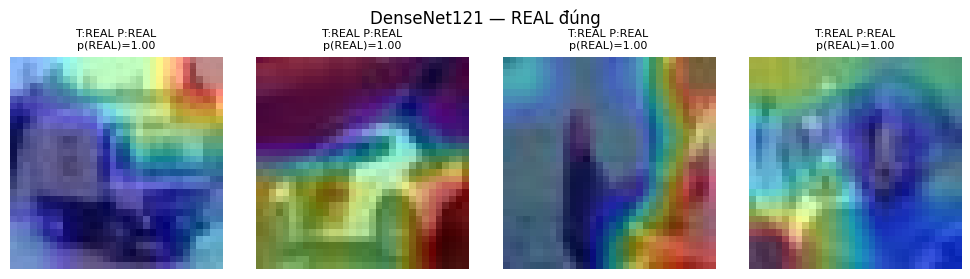

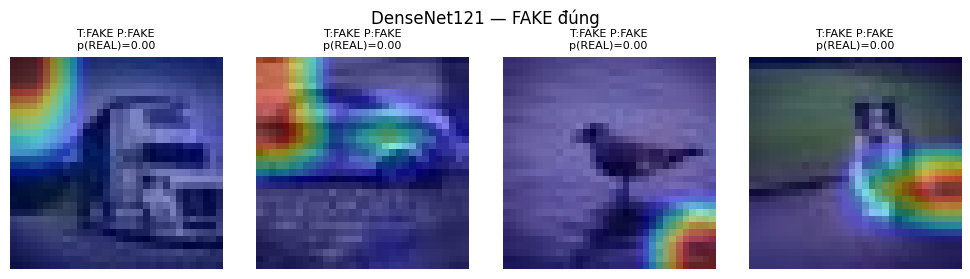

In [18]:
def show_overlays(rows, title):
    n = len(rows)
    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 2.8))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, rows.iterrows()):
        original = np.array(Image.open(PROJECT_ROOT / row["image_path"]).convert("RGB"))
        heatmap = np.load(PROJECT_ROOT / row["heatmap_path"])
        ax.imshow(original)
        ax.imshow(heatmap, cmap="jet", alpha=0.45)
        ax.set_title(
            f"T:{row['true_label']} P:{row['pred_label']}\np(REAL)={row['prob_real']:.2f}",
            fontsize=8,
        )
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

dense = df[df["model"] == "densenet121"]
correct_real = dense[(dense["true_label"] == "REAL") & (dense["correct"] == 1)].head(4)
correct_fake = dense[(dense["true_label"] == "FAKE") & (dense["correct"] == 1)].head(4)

show_overlays(correct_real, "DenseNet121 — REAL đúng")
show_overlays(correct_fake, "DenseNet121 — FAKE đúng")

**Nhận xét cần điền sau khi chạy:**
- Vùng "nóng" trên ảnh REAL thường rơi vào đâu? (chủ thể / nền / cạnh?)
- Vùng "nóng" trên ảnh FAKE có khác biệt rõ với ảnh REAL không?
- Có ảnh nào model dự đúng nhưng nhìn vào vùng "sai" (vd: nhìn vào nền) — dấu hiệu *shortcut learning*?

## Grad-CAM Observation: DenseNet121

### Correct REAL Samples

Với các ảnh REAL được dự đoán đúng, vùng nóng không chỉ tập trung vào toàn bộ chủ thể chính. Một số ảnh có vùng chú ý nằm trên cạnh/biên của object, ví dụ vùng thân xe, cửa xe, đầu/thân con vật, nhưng cũng có ảnh heatmap lan sang nền hoặc vùng chuyển màu phía sau.

Điều này cho thấy model có dùng thông tin từ chủ thể, nhưng không hoàn toàn dựa vào semantic object. Nó có thể đang học thêm texture, biên ảnh, độ nhiễu, hoặc pattern nền.

### Correct FAKE Samples

Với các ảnh FAKE được dự đoán đúng, heatmap nhìn khá rộng và mờ, không tập trung sắc nét vào một chi tiết duy nhất. Một số vùng chú ý nằm quanh object, nhưng cũng có xu hướng lan vào background.

So với ảnh REAL, ảnh FAKE có vẻ không tạo ra một vùng nóng rõ ràng hơn hẳn. Điều này phù hợp với nhận xét trong paper: model có thể không chỉ nhìn vào vật thể chính, mà chú ý đến các khác biệt nhỏ về texture/background/artifact.

### Shortcut Learning

Có dấu hiệu shortcut learning nhẹ. Một vài ảnh model dự đoán đúng nhưng vùng Grad-CAM không nằm hoàn toàn trên object chính, mà lan sang nền hoặc vùng biên. Điều này cho thấy model có thể đang dựa vào các dấu hiệu phụ như texture nền, độ mượt, nhiễu ảnh, hoặc artifact sinh ảnh thay vì hiểu “xe”, “chim”, “cú” theo nghĩa semantic.

### Note

Do ảnh CIFAKE chỉ có kích thước 32x32, Grad-CAM khá thô và khó diễn giải chi tiết. Heatmap nên được hiểu như tín hiệu định tính, không phải bằng chứng tuyệt đối.

## 3. Các trường hợp dự đoán SAI

Đây là phần quan trọng nhất: model thất bại khi nào, và *vì sao*?

Số case sai của DenseNet121 (trong 100 mẫu): 3

Top case sai TỰ TIN NHẤT (model rất chắc nhưng sai):


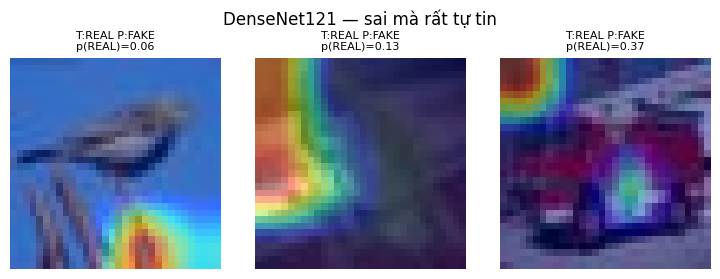


Top case sai MƠ HỒ NHẤT (xác suất sát 0.5):


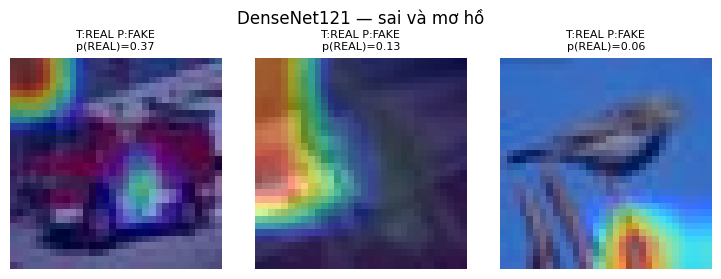

In [19]:
wrong = dense[dense["correct"] == 0].copy()
wrong["confidence"] = (wrong["prob_real"] - 0.5).abs()
print(f"Số case sai của DenseNet121 (trong 100 mẫu): {len(wrong)}")

if len(wrong) > 0:
    print()
    print("Top case sai TỰ TIN NHẤT (model rất chắc nhưng sai):")
    top_wrong = wrong.sort_values("confidence", ascending=False).head(min(4, len(wrong)))
    show_overlays(top_wrong, "DenseNet121 — sai mà rất tự tin")
    print()
    print("Top case sai MƠ HỒ NHẤT (xác suất sát 0.5):")
    border = wrong.sort_values("confidence").head(min(4, len(wrong)))
    show_overlays(border, "DenseNet121 — sai và mơ hồ")
else:
    print("Không có case sai trong 100 mẫu đầu — thử mở rộng dataset.")

**Câu hỏi để trả lời sau khi chạy:**
1. Loại sai nào phổ biến hơn — false-positive (FAKE bị nhận thành REAL) hay false-negative?
2. Với case sai "tự tin": Grad-CAM có chỉ vào vùng *bất thường* (vd: artifact của ảnh FAKE) hay vào vùng vô nghĩa?
3. Với case sai "mơ hồ": vùng attention có bị phân tán không?

Trong 100 mẫu được kiểm tra, DenseNet121 sai 3 mẫu và cả 3 đều là false-negative: ảnh REAL bị dự đoán thành FAKE. Các case sai tự tin không cho thấy Grad-CAM tập trung vào một artifact bất thường rõ ràng; vùng chú ý khá thô, lan giữa object và background. Điều này gợi ý model có thể bị đánh lừa bởi các ảnh REAL có texture mờ, nền phẳng hoặc chi tiết kém rõ, khiến chúng trông giống ảnh synthetic. Với các case sai mơ hồ, attention cũng phân tán và không tập trung sắc nét vào chủ thể, cho thấy quyết định của model có thể dựa trên các tín hiệu yếu hoặc shortcut cues thay vì đặc trưng semantic rõ ràng.

Do ảnh chỉ có độ phân giải 32x32, các heatmap Grad-CAM cần được hiểu như bằng chứng định tính ở mức vùng thô, không phải giải thích pixel-level chính xác.

## 4. So sánh 4 model trên cùng ảnh

4 kiến trúc khác nhau (SimpleCNN / ResNet18 / EfficientNet-B0 / DenseNet121) có chú ý cùng một vùng không?

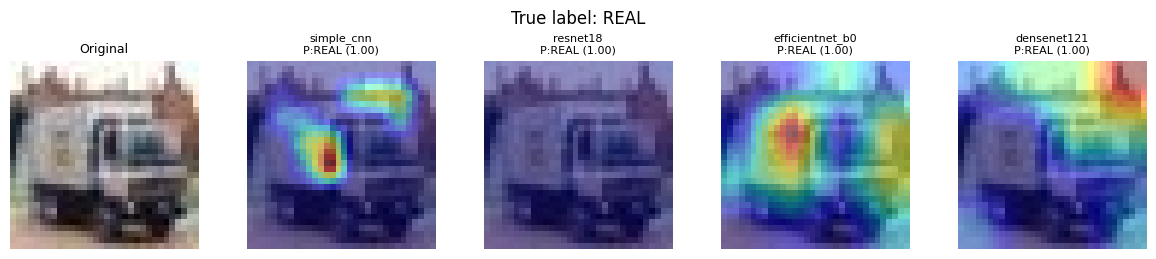

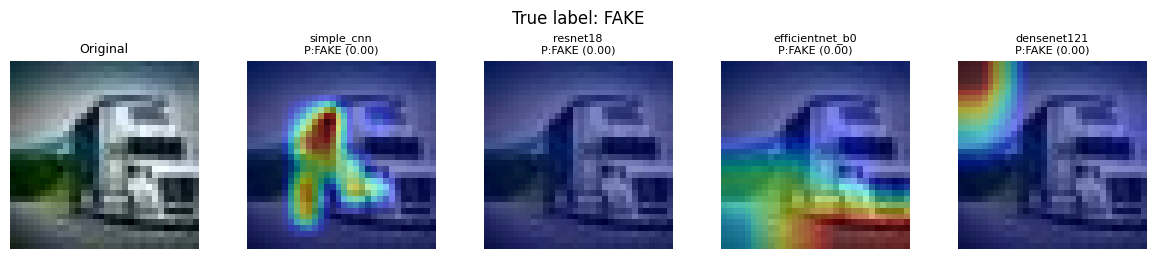

In [20]:
MODELS = ["simple_cnn", "resnet18", "efficientnet_b0", "densenet121"]

def compare_models_on_image(image_path):
    fig, axes = plt.subplots(1, len(MODELS) + 1, figsize=(2.4 * (len(MODELS) + 1), 2.6))
    original = np.array(Image.open(PROJECT_ROOT / image_path).convert("RGB"))
    axes[0].imshow(original)
    axes[0].set_title("Original", fontsize=9)
    axes[0].axis("off")
    true_label = None
    for ax, model_name in zip(axes[1:], MODELS):
        row = df[(df["model"] == model_name) & (df["image_path"] == str(image_path))].iloc[0]
        true_label = row["true_label"]
        heatmap = np.load(PROJECT_ROOT / row["heatmap_path"])
        ax.imshow(original)
        ax.imshow(heatmap, cmap="jet", alpha=0.45)
        ax.set_title(
            f"{model_name}\nP:{row['pred_label']} ({row['prob_real']:.2f})",
            fontsize=8,
        )
        ax.axis("off")
    fig.suptitle(f"True label: {true_label}")
    plt.tight_layout()
    plt.show()

sample_real = df[(df["model"] == "densenet121") & (df["true_label"] == "REAL")].iloc[0]["image_path"]
sample_fake = df[(df["model"] == "densenet121") & (df["true_label"] == "FAKE")].iloc[0]["image_path"]
compare_models_on_image(Path(sample_real))
compare_models_on_image(Path(sample_fake))

Khi so sánh cùng một ảnh giữa các model, SimpleCNN tạo heatmap có vùng nóng rõ hơn, trong khi ResNet18, EfficientNet-B0 và DenseNet121 cho heatmap mờ và phân tán hơn. Điều này chưa chắc có nghĩa SimpleCNN giải thích tốt hơn; có thể do các model sâu downsample ảnh 32x32 mạnh hơn, làm feature map cuối quá thô khi dùng Grad-CAM. Vì vậy, so sánh độ “tập trung” giữa các model cần thận trọng và phụ thuộc vào target layer được chọn.

## 5. Phân tích định lượng heatmap

Thay vì chỉ "nhìn bằng mắt", ta đo các chỉ số:
- **coverage**: tỉ lệ pixel có giá trị ≥ 0.5 (vùng nóng chiếm bao nhiêu % ảnh)
- **entropy**: độ tản của attention (cao = trải đều, thấp = tập trung)
- **center_mass_(x,y)**: tâm khối lượng vùng nóng (0–1, 0.5 = giữa ảnh)

In [21]:
def normalize_heatmap(heatmap):
    heatmap = heatmap.astype(np.float32)
    h_min = heatmap.min()
    h_max = heatmap.max()

    if h_max > h_min:
        return (heatmap - h_min) / (h_max - h_min)

    return np.zeros_like(heatmap)


def heatmap_stats_normalized(heatmap, threshold=0.5):
    heatmap = normalize_heatmap(heatmap)

    h, w = heatmap.shape
    total = heatmap.sum()

    coverage = float((heatmap >= threshold).mean())
    peak_value = float(heatmap.max())

    if total > 0:
        ys, xs = np.mgrid[0:h, 0:w]
        center_mass_y = float((ys * heatmap).sum() / total / (h - 1))
        center_mass_x = float((xs * heatmap).sum() / total / (w - 1))
    else:
        center_mass_x = 0.5
        center_mass_y = 0.5

    flat = heatmap.flatten()
    flat_sum = flat.sum()

    if flat_sum > 0:
        p = flat / flat_sum
        p = p[p > 0]
        entropy = float(-(p * np.log(p)).sum())
        normalized_entropy = float(entropy / np.log(flat.size))
    else:
        entropy = 0.0
        normalized_entropy = 0.0

    return {
        "coverage": coverage,
        "center_mass_x": center_mass_x,
        "center_mass_y": center_mass_y,
        "peak_value": peak_value,
        "entropy": entropy,
        "normalized_entropy": normalized_entropy,
    }


records = []
for _, row in df.iterrows():
    h = np.load(PROJECT_ROOT / row["heatmap_path"])
    stats = heatmap_stats_normalized(h)
    records.append({**row.to_dict(), **stats})

stats_df = pd.DataFrame(records)
summary = stats_df.groupby("model")[
    [
        "coverage",
        "normalized_entropy",
        "peak_value",
    ]
].mean().round(3)

print("Trung bình theo model sau khi chuẩn hóa heatmap:")
print(summary)

Trung bình theo model sau khi chuẩn hóa heatmap:
                 coverage  normalized_entropy  peak_value
model                                                    
densenet121         0.203               0.817        0.94
efficientnet_b0     0.277               0.926        1.00
resnet18            0.061               0.534        0.66
simple_cnn          0.052               0.701        0.93


DenseNet121 là model tốt nhất về phân loại, nhưng nó không phải model nhìn tập trung nhất.

In [22]:
by_correct = stats_df.groupby(["model", "correct"])[
    [
        "coverage",
        "normalized_entropy",
    ]
].mean().round(3)

print("Đúng (1) vs Sai (0):")
print(by_correct)

Đúng (1) vs Sai (0):
                         coverage  normalized_entropy
model           correct                              
densenet121     0           0.107               0.798
                1           0.206               0.818
efficientnet_b0 0           0.242               0.933
                1           0.280               0.926
resnet18        0           0.045               0.399
                1           0.062               0.542
simple_cnn      0           0.034               0.597
                1           0.053               0.707


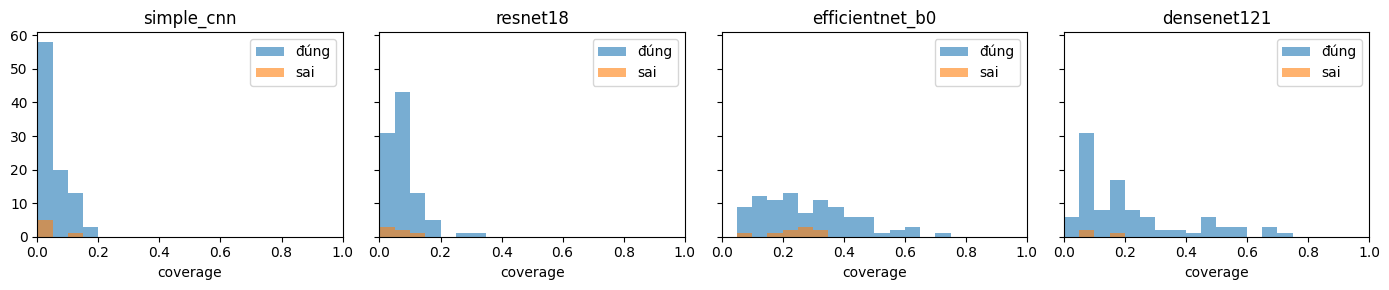

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)

for ax, model_name in zip(axes, MODELS):
    sub = stats_df[stats_df["model"] == model_name]

    ax.hist(
        sub[sub["correct"] == 1]["coverage"],
        bins=20,
        range=(0, 1),
        alpha=0.6,
        label="đúng",
    )

    if (sub["correct"] == 0).any():
        ax.hist(
            sub[sub["correct"] == 0]["coverage"],
            bins=20,
            range=(0, 1),
            alpha=0.6,
            label="sai",
        )

    ax.set_title(model_name)
    ax.set_xlabel("coverage")
    ax.set_xlim(0, 1)
    ax.legend()

plt.tight_layout()
plt.show()

**Đọc số liệu:**
- Nếu coverage trung bình của case **sai** > case **đúng** → khi model bối rối, nó "trải attention" ra nhiều vùng → đây là tín hiệu định lượng cho confidence.
- Entropy thấp + coverage thấp + accuracy cao → model học được đặc trưng định vị tốt (tập trung vào vùng có nghĩa).

## 6. Kết luận

### 6.1 Trả lời câu hỏi nghiên cứu
> *"Model học được gì để phân biệt ảnh thật vs ảnh AI?"*

Từ các kết quả Grad-CAM, model không chỉ dựa vào chủ thể chính trong ảnh. Trên nhiều mẫu, vùng chú ý lan sang cả nền, biên vật thể và các vùng texture. Điều này cho thấy model có thể học các dấu hiệu cấp thấp như độ mờ, texture, nền, viền vật thể hoặc artifact sinh ảnh, thay vì chỉ dựa vào đặc trưng semantic như “xe”, “chim”, “mèo”.

- Trên ảnh REAL, model thường tập trung vào một phần chủ thể chính như thân xe, biên vật thể hoặc vùng có contrast rõ. Tuy nhiên, attention cũng nhiều lần lan sang background, cho thấy model không chỉ nhìn vào object.
- Trên ảnh FAKE, model cũng không luôn tập trung vào một artifact riêng biệt. Vùng nóng thường nằm rải trên object, nền hoặc khu vực texture mờ. Điều này gợi ý model đang dùng các dấu hiệu tổng hợp như texture, độ mượt, nhiễu ảnh hoặc pattern nền để phân biệt ảnh AI.
- Khác biệt định lượng giữa case đúng và case sai chưa đủ mạnh để kết luận rằng coverage cao/thấp trực tiếp gây ra lỗi. Tuy nhiên, histogram coverage cho thấy các model có hành vi chú ý khác nhau: SimpleCNN và ResNet18 thường có vùng chú ý hẹp, EfficientNet-B0 có attention rộng và phân tán hơn, còn DenseNet121 linh hoạt hơn, có ảnh chú ý hẹp và có ảnh chú ý rộng. DenseNet121 đạt kết quả phân loại tốt nhất, nhưng không phải model có attention tập trung nhất.

Kết luận chính: model có khả năng phân biệt ảnh thật và ảnh AI không chỉ bằng cách nhận diện vật thể, mà bằng cách khai thác nhiều tín hiệu thị giác nhỏ trên toàn ảnh, đặc biệt là texture, background và artifact-level cues.

### 6.2 Hạn chế phát hiện được

- Ảnh CIFAKE có độ phân giải rất thấp, chỉ 32x32, nên Grad-CAM khá thô và khó diễn giải chi tiết. Heatmap chỉ nên được xem là giải thích định tính ở mức vùng, không phải bằng chứng pixel-level chính xác.
- Kết quả Grad-CAM phụ thuộc mạnh vào target layer được chọn. Với các model sâu, nếu chọn layer quá cuối, feature map chỉ còn 1x1 và heatmap trở nên vô nghĩa. Vì vậy việc chọn layer ảnh hưởng lớn đến kết quả giải thích.
- Một số heatmap khá phân tán hoặc không chỉ rõ artifact cụ thể, nên khó khẳng định chính xác model đang dựa vào đặc điểm nào.
- Model có dấu hiệu shortcut learning: đôi khi dự đoán đúng nhưng vùng chú ý nằm ở background hoặc texture thay vì chủ thể chính.
- Phân tích hiện tại mới dựa trên một tập mẫu giới hạn, chưa bao phủ toàn bộ test set, nên kết luận chỉ mang tính quan sát và định hướng.

### 6.3 Hướng mở rộng (cho phần "Future work" trong đồ án)
- Thử thêm phương pháp XAI khác: **LIME** (giải thích bằng perturbation), **SHAP** (đóng góp từng vùng).
- Phân tích Grad-CAM theo **lớp con** (vd: FAKE từ Stable Diffusion vs từ GAN) — yêu cầu dataset có nhãn nguồn.
- Đo độ tin cậy của Grad-CAM bằng **deletion / insertion metric**.

### 6.4 Tham khảo
- Selvaraju et al., *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization*, ICCV 2017.
- Bird & Lotfi, *CIFAKE: Image Classification and Explainable Identification of AI-Generated Synthetic Images*, 2023.